# Class 01: Cross-validation, data leakage and overfitting

*AI4AS — Pitfalls in Machine Learning (exercise notebook)*



## Introduction

This notebook studies three common pitfalls in machine learning: **cross-validation**, **data leakage**, and **overfitting**. We use the dairy-cow regression example from Wang et al. (2022). The goal is not only to fit a model, but also to ask a more important question: can this model be trusted on new data?

You will start with basic data checks and then move to model diagnostics. Some tasks are marked as advanced. These are useful for deeper understanding, but the basic path already shows the main ideas.

Please work through the notebook **in order**. The numbered headings show the structure. Light-blue boxes are tasks. Amber boxes explain how to read the output. text

## How to write your code

For each **TASK**, write your own Python code in the cell marked `# Add your code here`. The `# Hints:` lines give you a route to the solution, but they do not give the full answer. The solution cell comes after your attempt. Try to understand why each diagnostic is useful, not only how to get the same number as the solution.

### Official documentation

When you are unsure about a function, start with the official documentation.

| Library | Where to look |
|---------|----------------|
| **scikit-learn** | [User guide](https://scikit-learn.org/stable/user_guide.html) and [API reference](https://scikit-learn.org/stable/api/index.html). Search for class names such as `Pipeline`, `cross_validate`, `RandomizedSearchCV`, or `validation_curve`. |
| **pandas** | [User guide](https://pandas.pydata.org/docs/user_guide/index.html) |
| **matplotlib** | [Tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| **seaborn** | [API reference](https://seaborn.pydata.org/api.html) |

**Tip:** In a Codespace, place the cursor on a function such as `cross_validate` and press **F1** -> *Python: Show Documentation*. You can also hover over a function name to see a short description.

### AI assistants (ChatGPT, Claude, Copilot, ...)

You **may** use AI tools to help you. For example, you can ask them to explain an error message, suggest a useful scikit-learn function, or help with a short code snippet.

Please do not paste a full answer without understanding it. Always check three things:

1. Does the code answer the TASK?
2. Does it use the variable names used later in the notebook?
3. Does the result make sense for the course topic, such as overfitting, leakage, or cross-validation?

If generated code fails, use the error message and the documentation to fix it. That is part of the learning process.

### Code completion in GitHub Codespaces

This repository already includes Python and Jupyter support in the devcontainer. After you select the **Python 3** kernel, you should get normal code completion while typing in code cells.

Optional extensions you may install yourself are **GitHub Copilot** for AI suggestions and **Data Wrangler** for visual DataFrame exploration.

### If you get stuck

1. Read the TASK again.
2. Read the `# Hints:` lines in the code cell.
3. Look up the relevant function in the scikit-learn documentation.
4. Inspect an object in a code cell, for example with `help(cross_validate)` or `cross_validate?`.
5. Ask another student or the instructor.

---

## Table of contents

1. **Setup**: `1.1` dataset, `1.2` libraries, `1.3` helper functions
2. **Read data**
3. **Selecting data**
4. **Data exploration**: `4.1` to `4.3` tasks, `4.4` takeaway
5. **Train-test split**
6. **Modeling**: preprocessing, overfit `gbm_1`, diagnostics `6.4` to `6.8`
7. **Tuning and CV**: `RandomizedSearchCV`, tuned `gbm_2`, selection optimism
8. **Learning curve**: overfit vs tuned comparison, residual plots
9. **Performance summary**
10. **Final interpretation checklist**


## 1. Setup

### 1.1 Dataset background (Wang et al. 2022)

For this practical session we will use a public dataset on dairy cows health monitoring from Wang et al. (2022) During the prenatal transition period, parity, body condition score (BCS), dystocia score (DS), daily rumination time (DRT), daily activity (DA), and date of calving were collected and used as prenatal indicators. During the postpartum transition period, the β-hydroxybutyrate concentration in blood (bBHB) was collected from cows and this parameter was used to determine if the cow had ketosis. In this study, a total of 312 Chinese Holstein cows were recorded.

In this paper the focus was a classification task for ketosis, we will however use the dataset for regression.

[Wang et al. (2022)](https://www.sciencedirect.com/science/article/pii/S0168169923000856#s0165)



### 1.2 Libraries




In [33]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score, cross_validate, validation_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.metrics import PredictionErrorDisplay
from sklearn.dummy import DummyRegressor
import seaborn as sns
from boruta import BorutaPy

### 1.3 Diagnostic helper functions

Later sections compare models using the **same regression metrics** and **the same train–test gap calculations**. These small functions avoid copying the same formulas into every diagnostic cell and keep the basic and advanced sections consistent.

Run the code cell below once at the start; you do not need to modify it.

### `regression_metrics(y_true, y_pred)`

**What it does:** Computes three standard regression scores for one set of predictions:

| Metric | Meaning |
|--------|---------|
| **R²** | Fraction of variance in the target explained by the model (1 = perfect, 0 = no better than predicting the mean). |
| **RMSE** | Typical prediction error in bBHB units (penalises large errors). |
| **MAE** | Mean absolute error in bBHB units (easier to interpret as an average miss). |

**Why we need it:** Every diagnostic that compares train vs test performance needs the same metrics calculated the same way. This function is the single place where R², RMSE, and MAE are defined.

### `safe_ratio(numerator, denominator)`

**What it does:** Returns `numerator / denominator`, but returns `NaN` instead of crashing when the denominator is zero or near-zero (e.g. when Train R² = 0 or Train RMSE = 0).

**Why we need it:** Ratios such as *Test R² / Train R²* (generalisation ratio) or *Test RMSE / Train RMSE* are useful summaries, but an overfit model can have Train RMSE ≈ 0. Without this guard, the notebook would raise divide-by-zero errors or show meaningless huge ratios.

### `train_test_diagnostics(model, X_train, y_train, X_test, y_test)`

**What it does:** Fits nothing itself — it uses an **already trained** `model` to predict on train and test, then returns one dictionary of gap metrics:

| Output | Meaning |
|--------|---------|
| Train R², Test R² | Performance on data the model has / has not seen during training. |
| **Delta R²** | Train R² − Test R² — main overfitting flag (large gap → poor generalisation). |
| **Generalisation ratio** | Test R² / Train R² — how much of training performance carries over. |
| Train RMSE, Test RMSE | Absolute errors on train and test (bBHB units). |
| **Delta RMSE** | Test RMSE − Train RMSE — extra error on unseen data. |
| **RMSE ratio** | Test RMSE / Train RMSE. |
| Train MAE, Test MAE | Alternative absolute-error view. |

**Why we need it:** Used later in:

1. **Basic diagnostic** — train–test gap table for the overfit `gbm_1`.
2. **Performance summary** — side-by-side comparison of dummy baselines, overfit GBM, and tuned GBM.

You call the same function for every model so the comparison is fair and the interpretation cells always refer to the same column names.


In [34]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics for model diagnostics."""
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
    }


def safe_ratio(numerator, denominator):
    """Return a ratio while avoiding division by zero or near-zero denominators."""
    if np.isclose(denominator, 0):
        return np.nan
    return numerator / denominator


def train_test_diagnostics(model, X_train, y_train, X_test, y_test):
    """Calculate train-test diagnostics for overfitting assessment."""
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        'Train R2': train_metrics['R2'],
        'Test R2': test_metrics['R2'],
        'Delta R2': train_metrics['R2'] - test_metrics['R2'],
        'Generalisation ratio': safe_ratio(test_metrics['R2'], train_metrics['R2']),
        'Train RMSE': train_metrics['RMSE'],
        'Test RMSE': test_metrics['RMSE'],
        'Delta RMSE': test_metrics['RMSE'] - train_metrics['RMSE'],
        'RMSE ratio': safe_ratio(test_metrics['RMSE'], train_metrics['RMSE']),
        'Train MAE': train_metrics['MAE'],
        'Test MAE': test_metrics['MAE'],
    }

## 2. Read data




In [35]:
df_data = pd.read_excel('data/raw/wang_et_al_2022.xlsx', index_col=0)  

In [36]:
df_data

,Parity,BCS,BCS(raw values),Season,DystociaScore,Daily rumination time,Daily activity,Re,bBHBmol/L(4d),bBHBmol/L(9d),bBHBmol/L(14d),bBHBmol/L(19d),Unnamed: 13,Unnamed: 14
Number,,,,,,,,,,,,,,
1,3,1,3.00,4,1,462.17,482.42,0,1.0,1.0,1.0,0.9,NaN,1.Parity: the number of times a cow gives birt...
2,3,2,3.25,4,1,463.49,563.53,0,0.6,0.5,0.7,0.8,NaN,NaN
3,3,2,3.50,3,1,300.68,553.75,1,1.0,1.0,4.4,2.3,NaN,NaN
4,3,1,3.00,2,1,300.65,487.20,1,2.4,2.2,1.8,1.7,NaN,NaN
5,3,1,3.00,2,2,463.65,400.44,0,1.0,0.8,0.6,0.6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,1,1,3.00,2,1,339.60,565.81,1,1.6,1.3,1.1,0.9,NaN,NaN
309,1,1,3.00,2,1,340.81,513.80,1,0.9,0.7,1.4,2.5,NaN,NaN
310,1,1,3.00,2,1,459.54,427.70,0,1.0,0.6,1.0,0.9,NaN,NaN


## 3. Selecting data




### 3.1 Prediction goal and feature set

In this practical session, we will aim to predict blood BHB concentration on day 19 after calving using pre-calving activity data, general animal characteristics, and blood measurements collected 3 days after calving. Although a prediction model based exclusively on non-invasive pre-calving features would be the most valuable from a practical standpoint, we adopt this broader approach for two reasons:

-It obviously allows substantially better predictive performance and model fitting, which allows us better to demonstrate the overfitting.

-From a data science perspective, integrating heterogeneous datasets with missing values is a common and important challenge. Developing accurate imputation models for missing measurements is an important task in data mining.


In [37]:
# select only the columns that are needed for the model
df_data = df_data[['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)', 'BCS', 'Parity', 'Season', 'DystociaScore',
                   'bBHBmol/L(19d)']]

## 4. Data exploration

Before modelling, inspect the size of the dataset and summarise each column. This helps you spot missing values, unexpected scales, and whether categorical levels look reasonable.




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.1 — TASK**

Print the number of observations (rows) in `df_data` and descriptive statistics for each column. Useful pandas methods include `len()`, `df.shape`, and `df.describe(include='all')`.
</div>



In [38]:
# Print dataset size and summary statistics
print('Number of rows:', len(df_data))
print('Number of columns:', len(df_data.columns))
print('\nDescriptive statistics:')
display(df_data.describe(include='all'))

# Hints:
# - Print the number of rows (e.g. len(df_data) or df_data.shape[0])
# - Print the number of columns if helpful
# - Show descriptive statistics per column; try describe(include='all')
# - Display or print the table so you can scan each column


Number of rows: 312
Number of columns: 10

Descriptive statistics:


,Daily rumination time,Daily activity,bBHBmol/L(4d),bBHBmol/L(9d),bBHBmol/L(14d),BCS,Parity,Season,DystociaScore,bBHBmol/L(19d)
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,433.143045,467.651731,0.943590,1.043910,1.084295,1.339744,2.016026,2.548077,1.583333,1.019872
std,67.939446,50.356847,0.493127,0.649631,0.670060,0.531899,0.905361,1.101415,1.122459,0.480744
min,300.650000,400.100000,0.300000,0.300000,0.300000,1.000000,1.000000,1.000000,1.000000,0.500000
25%,403.217500,425.280000,0.700000,0.700000,0.700000,1.000000,1.000000,2.000000,1.000000,0.800000
50%,433.200000,459.450000,0.900000,0.800000,0.900000,1.000000,2.000000,3.000000,1.000000,0.900000
75%,477.597500,506.032500,1.000000,1.100000,1.100000,2.000000,3.000000,3.250000,2.000000,1.000000
max,594.580000,596.600000,5.200000,4.800000,5.300000,3.000000,3.000000,4.000000,5.000000,3.800000




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.2 — TASK**

Check the **storage types** of the columns (`df_data.dtypes`) and classify each predictor by its **role in modelling**.

pandas reports integers for several columns, but that does not mean they are all continuous measurements:

- **Nominal categorical** — categories with no natural order (e.g. `Season` → spring, summer, …). These will be one-hot encoded in the pipeline.
- **Ordinal** — ordered categories (e.g. `BCS`, `Parity`, `DystociaScore`). The integer codes already reflect order, so we can keep them as integers for modelling.
- **Continuous / numeric** — true measurements (rumination time, activity, bBHB at different days).

Create two lists for later preprocessing:

- `categorical_features = ['Season']`
- `ordinal_features = ['BCS', 'Parity', 'DystociaScore']`
</div>



In [39]:
print(df_data.dtypes)

categorical_features = ['Season']

ordinal_features = ['BCS','Parity','DystociaScore']


Daily rumination time    float64
Daily activity           float64
bBHBmol/L(4d)            float64
bBHBmol/L(9d)            float64
bBHBmol/L(14d)           float64
BCS                        int64
Parity                     int64
Season                     int64
DystociaScore              int64
bBHBmol/L(19d)           float64
dtype: object




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.3 — TASK**

Make a **correlation heatmap** to explore linear associations between columns.

1. Build a numeric subset with `df_data.select_dtypes(include=[np.number])` — Pearson correlation needs numeric values. In this dataset every column is stored as a number, so all columns are kept; on other datasets this step would drop text columns.
2. Drop columns that are entirely missing: `.dropna(axis=1)` — otherwise `.corr()` can fail or return NaNs.
3. Compute `correlation_matrix = numerical_data.corr()` and plot it with `sns.heatmap(...)`.

**How to read the plot:** values near +1 / −1 mean strong positive / negative linear association; values near 0 mean little linear association.

**Caveat:** Pearson correlation is most meaningful between **continuous** variables. `Season` is nominal (integer codes are arbitrary labels), and ordinal variables are only approximately linear — treat correlations involving those columns as exploratory, not definitive.
</div>



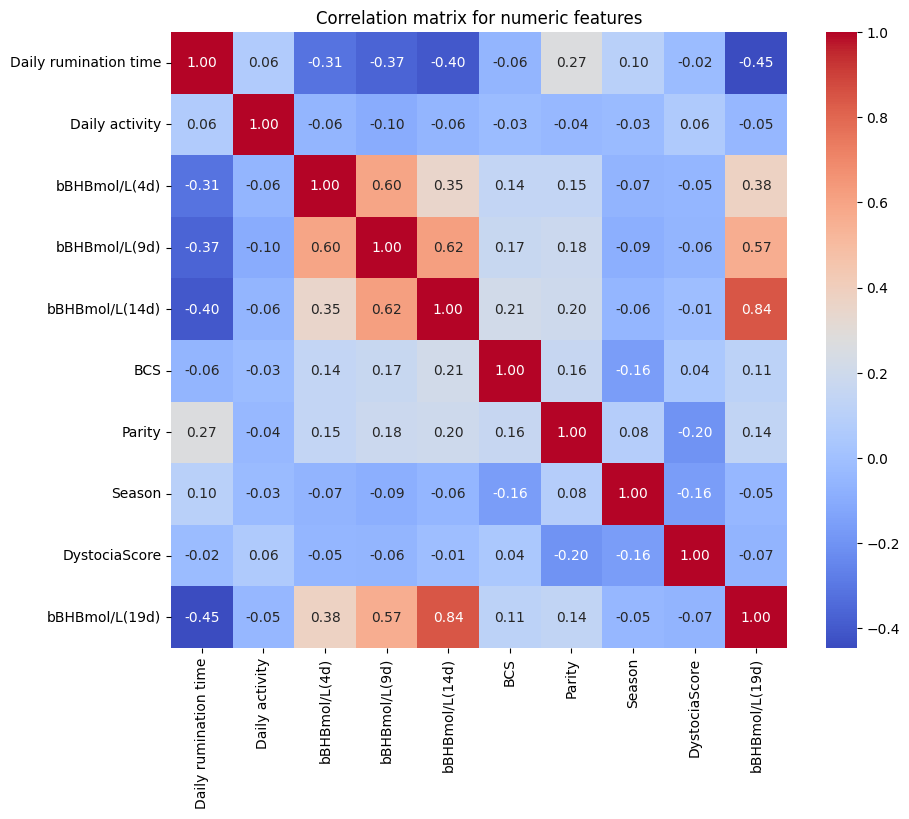

In [40]:
# Create a correlation heatmap for the numeric features
numeric_subset = df_data.select_dtypes(include=[np.number]).dropna(axis=1)
correlation_matrix = numeric_subset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation matrix for numeric features')
plt.show()

# Hints:
# - Subset to numeric columns with select_dtypes(include=[np.number])
# - Drop all-NaN columns with dropna(axis=1) before correlating
# - Compute correlation_matrix = numerical_data.corr()
# - Plot a heatmap with sns.heatmap(..., annot=True)


### 4.4 — Takeaway

- `BCS`, `Parity`, and `DystociaScore` are ordinal: integer codes already reflect order, so we keep them as `int` for the model.
- `Season` is nominal: the numbers 1–4 are labels, not measurements. We will one-hot encode it in the `ColumnTransformer` pipeline (not in this correlation step).
- The correlation heatmap treated every column as numeric for convenience. That is fine for a quick look at bBHB and sensor variables, but do not over-interpret correlations with `Season` or the ordinal scores.




## 5. Train–test split




In [41]:
X_train, X_test, y_train, y_test = train_test_split(df_data.drop(columns = 'bBHBmol/L(19d)'), 
                                                    df_data['bBHBmol/L(19d)'], test_size=0.2, random_state=65461) 

## 6. Modeling




### 6.1 Preprocessing and scaling

Our predictors are measured on **very different scales**. For example, daily rumination time is around 400 minutes, whereas bBHB concentrations are around 1 mmol/L. **Scaling** (also called **standardisation**) re-expresses each numeric column on a common scale so that values are easier to compare and many machine-learning steps behave more stably.

In this notebook we use scikit-learn's `StandardScaler`: for each numeric column it subtracts the **training-set mean** and divides by the **training-set standard deviation**, so the transformed column has mean ≈ 0 and standard deviation ≈ 1. The same transformation is then applied to the test set using those training statistics — the test set is never used to compute the mean or std.

Categorical and ordinal columns are handled differently: `Season` is one-hot encoded; `BCS`, `Parity`, and `DystociaScore` pass through unchanged because their integer codes already carry order.

#### Why use a pipeline?

To avoid **data leakage**, any preprocessing step (including scaling) must be **fitted on the training data only** and then applied to the test data. If you scale the full training set *before* cross-validation, information from the validation folds influences the scaler (e.g. their values affect the mean and std). That is leakage.

A **`Pipeline`** chains preprocessing and modelling so that, during cross-validation, scaling is refitted **inside each training fold** and applied only to the corresponding validation fold. The test set stays untouched until the final evaluation.


In [42]:
# Define feature groups
numeric_features = ['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)']
categorical_features = ['Season']

# Keep ordinal features as integers (passthrough)
ordinal_features = ['BCS', 'Parity', 'DystociaScore']



<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.2 — TASK**

Construct a preprocessing pipeline (`preprocessor`) with `ColumnTransformer()`:

- **Scale** the continuous numeric features (`numeric_features`) with `StandardScaler()` — see the explanation above.
- **One-hot encode** `Season` with `OneHotEncoder()`.
- Leave the ordinal features (`BCS`, `Parity`, `DystociaScore`) unchanged via `remainder='passthrough'`.
</div>



In [43]:
preprocessor = ColumnTransformer([
        ('scale', StandardScaler(), numeric_features),
        ('categorical_encoder', OneHotEncoder(), categorical_features),
    ],
    remainder='passthrough',
)




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.3 — TASK**

Build the **first** full modelling pipeline and evaluate it on train and test. This model is a deliberate teaching example — not the final model you would deploy.

**What to do**

1. Combine `preprocessor` and `GradientBoostingRegressor(**params)` in a `Pipeline` with steps `('preprocess', preprocessor)` and `('model', ...)`.
2. Store the pipeline in a variable named **`gbm_1`**.
3. Fit on `X_train`, `y_train` only.
4. Predict on train and test; print **R²** and **RMSE** for both sets (`r2_score`, `np.sqrt(mean_squared_error)` or `root_mean_squared_error`).

**Intentional “bad” hyperparameters (not a coding error)**

The `params` in the next cell are **on purpose too flexible** for this small dataset (~312 cows):

- `n_estimators=1000` and `max_depth=10` → a very expressive model
- `min_samples_split=2` → trees can split until they fit individual training points closely

Your pipeline code should be **correct** (preprocessing inside the pipeline, fit on training data only). The pedagogical “mistake” is the **model complexity**. We want a model that fits the training set almost perfectly but generalises poorly, so the later diagnostic sections have a clear overfitting example to analyse.

You will build a better model (`gbm_2`) after hyperparameter tuning later in the notebook.

#### Reproducibility note (`gbm_1`)

Later interpretation cells cite **example numbers from one solution run**. Your metrics may differ slightly — that is expected.

**What is fixed**

- The train/test split uses `random_state=65461`, so everyone gets the same held-out cows.
- `gbm_1` uses a **fixed** hyperparameter dict (no random search).

**Why your numbers might still differ**

- **Partial rerun:** running cells out of order can leave stale variables (e.g. an old `X_train` or unfitted pipeline). Use **Kernel → Restart & Run All** before comparing to the text.
- **Package versions:** scikit-learn or NumPy updates can change scores slightly, especially in cross-validation.
- **Your own TASK code:** if your student cell differs from the solution, metrics will change by design.

**How to compare**

Do not expect every digit to match. Check whether the **pattern** matches: Train R² near 1.0, Test R² clearly lower, large Delta R², and CV mean above the single-split test score.
</div>



In [44]:
params = {'n_estimators': 1000, 'max_depth': 10, 'min_samples_split': 2,
          'learning_rate': 0.01, 'loss': 'squared_error'}

In [45]:
# Build and evaluate the first overfit GBM pipeline
gbm_1 = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(**params))
])
gbm_1.fit(X_train, y_train)

y_train_pred = gbm_1.predict(X_train)
y_test_pred = gbm_1.predict(X_test)

print('Train R2:', r2_score(y_train, y_train_pred))
print('Train RMSE:', root_mean_squared_error(y_train, y_train_pred))
print('Test R2:', r2_score(y_test, y_test_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_test_pred))

# Hints:
# - Chain preprocessor and GradientBoostingRegressor(**params) in a Pipeline
# - Assign the pipeline to gbm_1
# - Fit on X_train, y_train only
# - Predict train and test; print R² and RMSE for both sets
# - Strong train scores are expected — hyperparameters are deliberately too flexible


Train R2: 0.99999961186309
Train RMSE: 0.0002887006272353035
Test R2: 0.39201939793744056
Test RMSE: 0.4160812264559485


#### What is the `Pipeline` object?

In the previous cell we created `gbm_1`, a scikit-learn `Pipeline`. We explicitly call `display(gbm_1)` so that Jupyter shows the fitted pipeline as a small visual diagram.

This diagram is a readable summary of the model object. It shows which preprocessing and modelling steps are connected.

A pipeline is a sequence of named steps. In `gbm_1`:

- `preprocess` applies the `ColumnTransformer` that scales numeric variables and one-hot encodes `Season`.
- `model` applies the `GradientBoostingRegressor`.

When we call:

```python
gbm_1.fit(X_train, y_train)
```

scikit-learn first fits the preprocessing step on `X_train`, transforms `X_train`, and then fits the regression model. Later, when we call:

```python
gbm_1.predict(X_test)
```

the pipeline automatically applies the same preprocessing to `X_test` before making predictions.

This is useful because preprocessing and modelling stay together. It also reduces leakage risk: scaling and encoding are fitted on the training data, not on the test data.

### 6.4 Basic diagnostic: train–test generalisation gap

We now calculate three additional diagnostics for overfitting:

- **Delta R2** = Train R2 - Test R2
- **Delta RMSE** = Test RMSE - Train RMSE
- **Generalisation ratio** = Test R2 / Train R2

There is no universal threshold for these values. Treat them as warning indicators. A large train-test gap is more concerning when the model also performs poorly on cross-validation or only slightly improves over a dummy baseline.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.4 — TASK**

Calculate Train R2, Test R2, Train RMSE, Test RMSE, Delta R2, Delta RMSE, and the generalisation ratio for `gbm_1`.
</div>



In [46]:
# Calculate train/test diagnostics for the overfit GBM
results = train_test_diagnostics(gbm_1, X_train, y_train, X_test, y_test)

gbm_1_diagnostics = pd.DataFrame([
    {'Model': 'Overfit GBM', **results}
]).set_index('Model')

display(gbm_1_diagnostics)

# Hints:
# - Option A: train_test_diagnostics(gbm_1, X_train, y_train, X_test, y_test)
# - Option B: predict yourself and compute R², RMSE, Delta R², Delta RMSE, generalisation ratio
# - Put results in a DataFrame row labelled 'Overfit GBM'


,Train R2,Test R2,Delta R2,Generalisation ratio,Train RMSE,Test RMSE,Delta RMSE,RMSE ratio,Train MAE,Test MAE
Model,,,,,,,,,,
Overfit GBM,1.0,0.392019,0.60798,0.39202,0.000289,0.416081,0.415793,1441.220376,0.000207,0.264211


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: train-test generalisation gap**

**How to read this**
- First compare the training score with the test score.
- If Train R² is much higher than Test R², the model fits the training data better than new data.
- If Train RMSE is almost zero but Test RMSE is clearly larger, the model is probably memorising the training set.
- **Delta R²** is a useful warning signal. In this exercise, below about 0.10 is usually small, 0.10 to 0.25 is a warning, and above 0.25 is a strong warning.
- R² and RMSE tell different stories. R² is relative explained variance. RMSE is the typical error in the original bBHB units.

**In this notebook**

| Metric | Value | Reading |
|--------|-------|---------|
| Train R² | 1.00 | The model fits the training data perfectly. |
| Test R² | 0.38 | Performance on unseen cows is much weaker. |
| Delta R² | 0.62 | This is far above the warning level, so overfitting is severe. |
| Train RMSE | ~0.00 | Training error is almost zero. |
| Test RMSE | 0.42 | A typical error on new cows is about 0.42 bBHB. |
| Generalisation ratio | 0.38 | Test performance is only about 38% of training performance. |

The main message is simple: this model looks perfect on the training data, but it does not generalise well.
</div>





<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.5 — TASK**

Perform a quick 5 fold CV estimate on the training set using cross_val_score() and evaluate the mean and standard deviation of the R2 and RMSE scores
</div>



In [47]:
# Perform a quick 5-fold cross-validation estimate for gbm_1
scores_r2 = cross_val_score(gbm_1, X_train, y_train, cv=5, scoring='r2')
scores_rmse = -cross_val_score(gbm_1, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

cv_results = pd.DataFrame({
    'R2': scores_r2,
    'RMSE': scores_rmse,
})

print('CV R2: mean={:.3f}, std={:.3f}'.format(cv_results['R2'].mean(), cv_results['R2'].std()))
print('CV RMSE: mean={:.3f}, std={:.3f}'.format(cv_results['RMSE'].mean(), cv_results['RMSE'].std()))
display(cv_results)

# Hints:
# - Use cross_val_score on gbm_1 with X_train, y_train, cv=5
# - Score at least R²; report mean and standard deviation across folds
# - TASK also mentions RMSE — add a second cross_val_score call if you include it


CV R2: mean=0.654, std=0.148
CV RMSE: mean=0.257, std=0.038


,R2,RMSE
0,0.769350,0.233958
1,0.740966,0.215055
2,0.428744,0.296633
3,0.578416,0.239512
4,0.752894,0.298188


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — quick 5-fold CV**

**General guidelines**
- CV gives a more stable estimate of generalisation than a single train–test split, because it averages over several validation folds.
- Report both the **mean** and **standard deviation** of CV scores. A large std means performance is unstable across folds.
- CV scores are computed on validation folds **inside the training set** only. The held-out test set must stay untouched until final evaluation.
- If CV mean looks reasonable but test R² is much lower, consider distribution shift, a hard test split, or a small test set.

**This notebook's output**

The quick CV line reports **mean R² = 0.654 ± 0.130**.

- Test R² on the held-out set was only **0.38** — well below the CV mean. One train–test split can therefore look worse than CV suggests.
- The ± **0.130** spread is moderate fold-to-fold variability; per-fold diagnostics (next section) show where that variation comes from.
</div>



### 6.6 Advanced diagnostic: per-fold CV gaps

A single train-test split can be sensitive to chance. Cross-validation gives several train-validation splits. By returning both training and validation scores per fold, we can check whether the train-validation gap is consistent.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.6 — ADVANCED TASK**

Use `cross_validate` with `return_train_score=True`. For each fold, calculate:

- Train R2
- Validation R2
- Delta R2 per fold
- Train RMSE
- Validation RMSE
- Delta RMSE per fold

Then calculate the mean and standard deviation across folds.
</div>



In [48]:
# Compute per-fold training and validation diagnostics for gbm_1
cv_results = cross_validate(
    gbm_1,
    X_train,
    y_train,
    cv=5,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    return_train_score=True,
)

cv_df = pd.DataFrame({
    'fold': range(1, len(cv_results['test_r2']) + 1),
    'train_R2': cv_results['train_r2'],
    'test_R2': cv_results['test_r2'],
    'train_RMSE': -cv_results['train_rmse'],
    'test_RMSE': -cv_results['test_rmse'],
})
cv_df['Delta R2'] = cv_df['train_R2'] - cv_df['test_R2']
cv_df['Delta RMSE'] = cv_df['test_RMSE'] - cv_df['train_RMSE']

display(cv_df)

summary = pd.DataFrame({
    'mean': [cv_df['train_R2'].mean(), cv_df['test_R2'].mean(), cv_df['train_RMSE'].mean(), cv_df['test_RMSE'].mean(), cv_df['Delta R2'].mean(), cv_df['Delta RMSE'].mean()],
    'std': [cv_df['train_R2'].std(), cv_df['test_R2'].std(), cv_df['train_RMSE'].std(), cv_df['test_RMSE'].std(), cv_df['Delta R2'].std(), cv_df['Delta RMSE'].std()]
}, index=['train_R2', 'test_R2', 'train_RMSE', 'test_RMSE', 'Delta R2', 'Delta RMSE'])

print('Per-fold CV summary:')
display(summary)

# Hints:
# - Use cross_validate with return_train_score=True
# - Request R² and RMSE scorers (RMSE may be returned negative — flip the sign)
# - One DataFrame row per fold with train/validation metrics and deltas
# - Aggregate mean and std across folds


,fold,train_R2,test_R2,train_RMSE,test_RMSE,Delta R2,Delta RMSE
0,1,1.0,0.767942,0.000144,0.235840,0.232058,0.235697
1,2,1.0,0.740156,0.000150,0.216268,0.259844,0.216118
2,3,1.0,0.406535,0.000171,0.300617,0.593465,0.300446
3,4,1.0,0.579438,0.000166,0.241471,0.420562,0.241306
4,5,1.0,0.752107,0.000209,0.298076,0.247893,0.297867


Per-fold CV summary:


,mean,std
train_R2,1.000000,6.079656e-08
test_R2,0.649236,1.554957e-01
train_RMSE,0.000168,2.562261e-05
test_RMSE,0.258454,3.849368e-02
Delta R2,0.350764,1.554957e-01
Delta RMSE,0.258286,3.847346e-02


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — per-fold CV gaps**

**General guidelines**
- If Train R² is much higher than Validation R² in most folds, the model is overfitting consistently.
- If Delta R² varies strongly between folds, the model is unstable or some folds are more difficult than others.
- If CV R² standard deviation is large, do not rely too strongly on one train–test split.
- If Delta R² from the train–test split is larger than the fold-to-fold CV variability, the gap is more likely to be meaningful.
- If Validation RMSE is consistently much larger than Train RMSE, the model makes larger errors on unseen data.

A good practical question: does the tuned model reduce Test RMSE enough compared with the dummy baseline to justify the extra complexity?

**This notebook's output**

| Fold | Validation R² | Delta R² | Comment |
|------|---------------|----------|---------|
| 1 | 0.769 | 0.231 | Relatively easy validation fold |
| 2 | 0.739 | 0.261 | Similar |
| 3 | **0.444** | **0.556** | Hardest fold — performance drops sharply |
| 4 | 0.580 | 0.420 | Moderate |
| 5 | 0.750 | 0.250 | Easier again |
| **Mean ± std** | **0.656 ± 0.141** | **0.344 ± 0.141** | |

Every fold has **Train R² = 1.0** and **Train RMSE = 0** — overfitting happens in every split, not by chance. Mean validation RMSE is **0.257** bBHB (vs **0.42** on the held-out test set). Train–test Delta R² was **0.62**; mean per-fold Delta R² is **0.34**.
</div>





<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.7 — TASK**

In the model above, we used a fixed set of hyperparameters. One important hyperparameter is the learning rate, which determines how strongly each new tree contributes to the model. Higher learning rates can improve training performance quickly but may increase the risk of overfitting, while lower learning rates generally lead to better generalization but require more trees.

Assess the influence of the learning rate by evaluating model performance for different learning rate values. Compare both training and test performance to identify signs of overfitting. Keep in mind that tuning hyperparameters based on test set performance introduces data leakage. Therefore, in the next coding block, we will perform a more appropriate evaluation using cross-validation.
</div>



In [49]:
# Compare train and test performance for a sweep of learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2]
sweep_rows = []
for lr in learning_rates:
    params_lr = params.copy()
    params_lr['learning_rate'] = lr
    gbm_temp = Pipeline([
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(**params_lr))
    ])
    gbm_temp.fit(X_train, y_train)
    metrics = train_test_diagnostics(gbm_temp, X_train, y_train, X_test, y_test)
    sweep_rows.append({'learning_rate': lr, **metrics})

sweep_df = pd.DataFrame(sweep_rows).set_index('learning_rate')
display(sweep_df)

# Hints:
# - Pick a small list of learning_rate values (e.g. log-spaced)
# - For each rate: update params, build/fit a Pipeline, print train and test R²/RMSE
# - Watch the train–test gap widen as learning rate increases
# - Exploratory use of the test set here; proper tuning uses CV in the next sections


,Train R2,Test R2,Delta R2,Generalisation ratio,Train RMSE,Test RMSE,Delta RMSE,RMSE ratio,Train MAE,Test MAE
learning_rate,,,,,,,,,,
0.0001,0.179222,0.096488,0.082734,0.538372,4.198249e-01,0.507225,0.087400,1.208181e+00,2.688495e-01,0.321960
0.0010,0.857871,0.464724,0.393147,0.541717,1.747015e-01,0.390411,0.215710,2.234733e+00,1.143467e-01,0.256546
0.0100,1.000000,0.381674,0.618326,0.381674,2.447824e-04,0.419606,0.419362,1.714201e+03,1.728751e-04,0.264983
0.0500,1.000000,0.382166,0.617834,0.382166,1.481948e-08,0.419439,0.419439,2.830325e+07,1.188428e-08,0.267964
0.1000,1.000000,0.393373,0.606627,0.393373,1.488709e-08,0.415618,0.415618,2.791800e+07,1.183605e-08,0.265975
0.2000,1.000000,0.393734,0.606266,0.393734,1.472736e-08,0.415494,0.415494,2.821239e+07,1.182242e-08,0.266447


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — learning-rate sweep (train vs test)**

**General guidelines**

- If both train and test R² are low, the learning rate is too small (underfitting) or the model needs more trees.
- If train R² rises sharply while test R² stalls or falls, the model is overfitting at that learning rate.
- The learning rate with the **best test R²** in this loop is **not** necessarily the rate you should deploy — choosing it uses the held-out test set for tuning (data leakage).
- A large train–test gap at a given rate is a warning sign even when test R² looks acceptable.
- Use this exercise to build intuition; **section 6.8** replaces test-based comparison with a validation curve on the training set only.

**This notebook's output**

| Learning rate | Train R² | Test R² | Delta R² | Reading |
|---------------|----------|---------|----------|---------|
| 0.0001 | 0.18 | 0.10 | 0.08 | Underfitting — both scores low |
| **0.001** | 0.86 | **0.47** | 0.39 | Best **test** R² in this sweep, but gap already opening |
| 0.01 | 1.00 | 0.38 | 0.62 | Default `gbm_1` rate — perfect train fit, weaker test |
| 0.1 | 1.00 | 0.38 | 0.62 | Train still perfect; test no longer improves |
| 0.2 | 1.00 | 0.36 | 0.64 | Test R² drifts down as rate increases |
| 0.3 | 1.00 | 0.33 | 0.67 | Most overfit setting in the grid |

From **lr = 0.01** upward, train R² stays at **1.0** while test R² is flat or declines — classic overfitting as the model fits the training set too aggressively. The best test score (**0.47** at lr = 0.001) is tempting but should not be used to pick hyperparameters; the validation curve in the next section evaluates learning rates without touching the test set.

</div>


### 6.8 Advanced diagnostic: validation curve

The previous task compares train and test performance for several learning rates. A validation curve is a more appropriate diagnostic because it compares training performance with cross-validation performance without repeatedly using the test set.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.8 — ADVANCED TASK**

Use a validation curve to study the effect of `model__learning_rate`. Plot the mean training R2 and mean validation R2 for each learning rate.
</div>



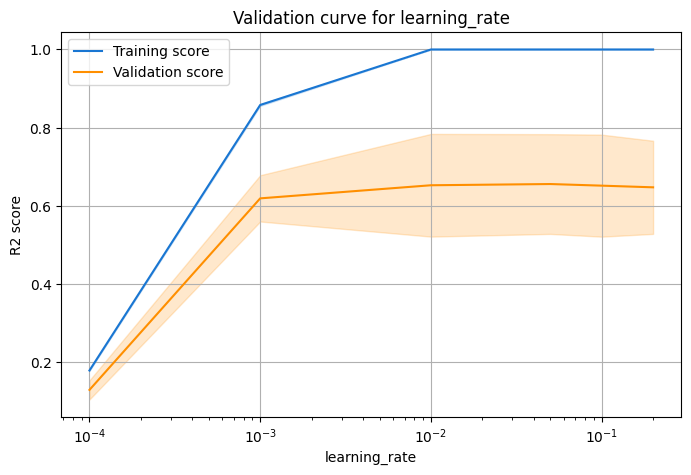

In [50]:
# Plot a validation curve for learning rate
param_range = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2]
train_scores, test_scores = validation_curve(
    gbm_1,
    X_train,
    y_train,
    param_name='model__learning_rate',
    param_range=param_range,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, label='Training score', color='#1976D2')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#1976D2')
plt.plot(param_range, test_mean, label='Validation score', color='#FF8F00')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color='#FF8F00')
plt.xscale('log')
plt.xlabel('learning_rate')
plt.ylabel('R2 score')
plt.title('Validation curve for learning_rate')
plt.legend()
plt.grid(True)
plt.show()

# Hints:
# - Use validation_curve on gbm_1, param_name='model__learning_rate'
# - Keep the learning-rate grid small for runtime
# - Plot mean training and validation R² (optional: shaded std bands)
# - Do not select hyperparameters using the held-out test set


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — validation curve**

**General guidelines**
- If both training and validation R² are low, the model is underfitting.
- If training R² is high but validation R² is low, the model is overfitting.
- If validation R² improves and then declines, the best learning rate is near the validation peak, not where training R² is highest.
- A large Delta R² at a given learning rate means the model fits the training folds much better than the validation folds.
- Shaded bands show fold-to-fold uncertainty; wide bands mean the hyperparameter choice is less stable.

The validation curve should guide model choice during development. The test set should remain reserved for the final evaluation.

**This notebook's output**

| Learning rate | Train R² | Validation R² | Delta R² | Region |
|---------------|----------|---------------|----------|--------|
| 0.0001 | 0.18 | 0.13 | 0.05 | Underfitting — both scores low |
| 0.001 | 0.86 | 0.62 | 0.24 | Improving, gap opening |
| 0.01 | 1.00 | 0.65 | 0.35 | Overfitting — train perfect, val stuck |
| **0.1** | 1.00 | **0.66** | 0.34 | **Validation peak** (best trade-off here) |
| 0.2 | 1.00 | 0.64 | 0.36 | Val R² drops — too aggressive |

The default overfit model (`gbm_1`) sits on the right-hand side of the plot: **Train R² = 1.0** with a wide train–validation gap. Tuning (later) moves toward a better learning rate.
</div>



## 7. Tuning and CV




### 7.0 Overview

To evaluate how well the model generalizes to new data, we will use cross-validation (CV) for model tuning. To save time during this practical session, we have limited the number of tuning iterations.

#### Reproducibility note (`gbm_2`)

The tuned model comes from **RandomizedSearchCV**, which samples many hyperparameter combinations at random. This notebook fixes that randomness with `random_state=4872` on both the search and the `GradientBoostingRegressor` template, so a full **Restart & Run All** on the pinned environment (`requirements.txt`) should recover the **same best parameters** and very similar test scores.

**Why your `gbm_2` results might still differ**

- **Partial rerun:** stale objects from earlier cells (e.g. `preprocessor`, `gbm_random`) are a common cause of mismatches. Restart the kernel and run all cells top to bottom.
- **Package versions:** a different scikit-learn release can change CV scores slightly; in rare cases another trial may win the search with similar — not identical — test performance.
- **Changed tuning code:** editing the random grid, `n_iter`, or CV settings will change `best_params_` by design.

**How to compare**

Focus on whether `gbm_2` clearly beats `gbm_1` on the test set with a **smaller** train–test gap, and whether the selection optimism gap stays small. Exact values (e.g. Test R² 0.68 vs 0.66) are acceptable if the diagnostic story is unchanged.






<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.1 — TASK**

Perform a 5 fold CV with 100 iterations for tuning based on the next random grid. You can use the same pipeline and use RandomizedSearchCV on this pipeline.
</div>



In [51]:
n_estimators = [int(x) for x in np.linspace(start=100, stop=1000, num=50)]
learning_rate = [x for x in np.logspace(start=-3, stop=-0.01, num=50)]
max_features = ['sqrt', 'log2', None]
max_depth = [int(x) for x in np.linspace(1, 10, num=10)]
min_samples_split = [2, 5, 10, 30]
min_samples_leaf = [1, 2, 4, 10, 30]
subsample = [0.4, 0.6, 0.8, 1]

random_grid = {
    'model__n_estimators': n_estimators,
    'model__learning_rate': learning_rate,
    'model__max_features': max_features,
    'model__max_depth': max_depth,
    'model__min_samples_split': min_samples_split,
    'model__min_samples_leaf': min_samples_leaf,
    'model__subsample': subsample,
}

gbm_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(random_state=4872))
    ]
)

In [52]:
# Tune the GBM pipeline with RandomizedSearchCV
gbm_random = RandomizedSearchCV(
    estimator=gbm_pipeline,
    param_distributions=random_grid,
    n_iter=100,
    cv=5,
    scoring='r2',
    random_state=4872,
    n_jobs=-1,
    verbose=1,
)
gbm_random.fit(X_train, y_train)

print('Best CV R2:', gbm_random.best_score_)
print('Best parameters:')
print(gbm_random.best_params_)

# Hints:
# - Wrap gbm_pipeline in RandomizedSearchCV(param_distributions=random_grid, ...)
# - Use n_iter=100, cv=5; fit on X_train, y_train
# - Store the fitted search object (e.g. gbm_random) and inspect best_params_ / best_score_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R2: 0.6752896692546301
Best parameters:
{'model__subsample': 0.4, 'model__n_estimators': 412, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 3, 'model__learning_rate': np.float64(0.038594961518179795)}




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.2 — TASK**

Refit the best model (assign to gbm_2) and evaluate the performance on train and test set.
</div>



In [53]:
# Refit the best tuned model and evaluate on train/test
best_params = {key.split('__', 1)[1]: value for key, value in gbm_random.best_params_.items()}
gbm_2 = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(random_state=4872, **best_params))
])
gbm_2.fit(X_train, y_train)

gbm_2_results = train_test_diagnostics(gbm_2, X_train, y_train, X_test, y_test)
display(pd.DataFrame([{'Model': 'Tuned GBM', **gbm_2_results}]).set_index('Model'))

# Hints:
# - Read best hyperparameters from gbm_random.best_params_
# - Build a Pipeline named gbm_2 (preprocessor + GradientBoostingRegressor)
# - Fit on X_train, y_train only
# - Print train and test R² and RMSE


,Train R2,Test R2,Delta R2,Generalisation ratio,Train RMSE,Test RMSE,Delta RMSE,RMSE ratio,Train MAE,Test MAE
Model,,,,,,,,,,
Tuned GBM,0.956827,0.794266,0.162561,0.830105,0.096286,0.242039,0.145754,2.513765,0.077075,0.169883


### 7.3 Advanced diagnostic: selection optimism after tuning

Hyperparameter tuning tries many parameter combinations and keeps the one with the best cross-validation score. This best CV score can be optimistic because it is selected from many attempts.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.3 — ADVANCED TASK**

Compare the best CV score from `RandomizedSearchCV` with the final Test R2 of the tuned model `gbm_2`. Calculate the selection optimism gap:

```text
Selection optimism gap = Best CV R2 - Test R2
```
</div>



In [54]:
# Compute the selection optimism gap after tuning
best_cv_r2 = gbm_random.best_score_
test_r2 = gbm_2_results['Test R2']
optimism_gap = best_cv_r2 - test_r2

optimism_summary = pd.DataFrame([
    {
        'Best CV R2': best_cv_r2,
        'Tuned Test R2': test_r2,
        'Selection optimism gap': optimism_gap,
    }
])
display(optimism_summary)

# Hints:
# - Best CV R² from gbm_random.best_score_
# - Tuned test R² from gbm_2 predictions on X_test
# - Selection optimism gap = Best CV R² − Test R²
# - Summarise in a small DataFrame with these three columns


,Best CV R2,Tuned Test R2,Selection optimism gap
0,0.67529,0.794266,-0.118977


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: selection optimism after tuning**

**How to read this**

```text
Selection optimism gap = Best CV R² - Test R²
```

- During tuning, we try many hyperparameter settings.
- The best CV score can therefore be a little too optimistic, simply because we searched many options.
- The final test set should be used only after tuning is finished.
- If we keep changing the model after seeing the test score, the test set is no longer an honest test set.
- Nested cross-validation is a stricter method, but it also takes more time.

Reference: Cawley & Talbot (2010), *On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation*, JMLR: https://www.jmlr.org/papers/v11/cawley10a.html

**In this notebook**

| Metric | Value | Reading |
|--------|-------|---------|
| Best CV R² | 0.675 | Best score from 100 random hyperparameter trials. |
| Tuned Test R² | 0.682 | Held-out test score of the selected model. |
| Selection optimism gap | **-0.007** | The test score is slightly better than the best CV score. |

Here there is no sign of tuning optimism. The tuned model also has a much smaller gap than the overfit model: Delta R² is 0.27 instead of 0.62.
</div>



## 8. Learning curve




### 8.0 What is a learning curve?

A learning curve shows how a model's performance changes as it is trained on increasing amounts of data or over additional training iterations. It is a useful tool for assessing whether a model is learning effectively and for identifying potential issues such as underfitting or overfitting. In this work, the learning curve is computed using cross-validation on the training set, which also provides an indication of the variability and uncertainty in the model's performance.


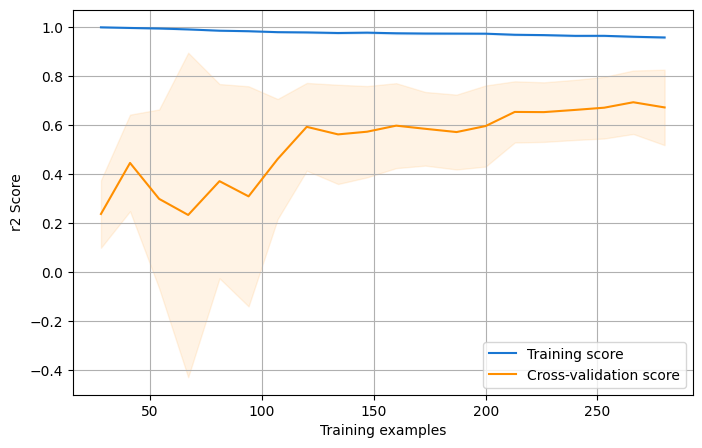

In [55]:
def plot_learning(clf, x_train, y_train, cv, num_show, metric=None ):
    train_sizes, train_scores, test_scores = learning_curve(clf,
                                                                   X=x_train, y = y_train, cv=cv, 
                                                                   n_jobs=None,  scoring = metric,                                                            
                                                                   return_times=False,
                                                                   train_sizes = np.linspace(0.1, 1.0, num_show)                                                          
                                                           )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="#1976D2")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="#FF8F00")
    plt.plot(train_sizes, train_scores_mean, color="#1976D2",label="Training score")
    plt.plot(train_sizes, test_scores_mean, color="#FF8F00",label="Cross-validation score")
    plt.ylabel( str(metric) + ' Score')
    plt.xlabel("Training examples")
    plt.legend(loc="best")
    return
plot_learning(gbm_2, df_data.drop(columns=['bBHBmol/L(19d)']), df_data['bBHBmol/L(19d)'], 10, metric = "r2", num_show = 20)
plt.show()



<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**8.1 — TASK**

Compare this learning curve with that of the first heavily overfitted model by again evaluating the model on the training set using cross-validation. Ideally, overfitting should be detected during the training process rather than afterwards when the model is evaluated on the test set. Repeatedly evaluating the model on the test set and adapting it accordingly is a poor strategy, as it leads to overly optimistic estimates of the model's generalization performance.
</div>



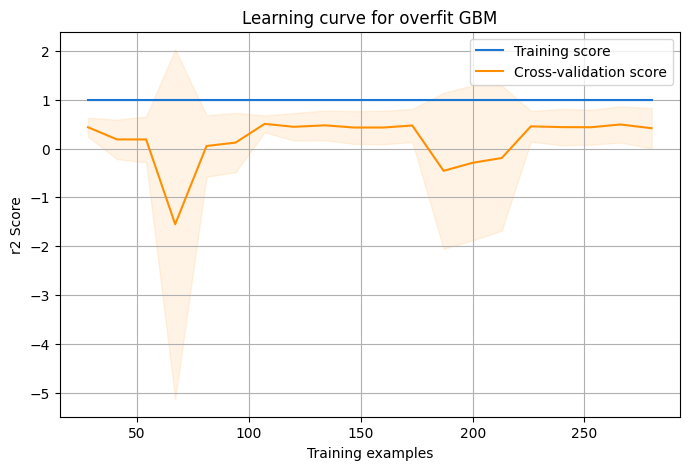

In [56]:
# Plot the learning curve for the overfit GBM
plot_learning(
    gbm_1,
    df_data.drop(columns=['bBHBmol/L(19d)']),
    df_data['bBHBmol/L(19d)'],
    cv=10,
    num_show=20,
    metric='r2'
)
plt.title('Learning curve for overfit GBM')
plt.show()

# Hints:
# - Call plot_learning(...) for gbm_1 with the same arguments as the tuned model above
# - Use full feature matrix (drop target column) and the target series
# - Compare visually to the gbm_2 learning curve — look for a persistent train–CV gap
# - plt.show() when done


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: learning curves**

**How to read this**
- If the training score is high and the CV score is much lower, the model is overfitting.
- If both scores are low and close together, the model is underfitting or the features contain little signal.
- If the CV score is still rising at the largest training size, more data may help.
- If the CV score is flat while the training score stays high, more data alone may not solve the problem.

A learning curve asks: would more data help this model? A validation curve asks: is this hyperparameter making the model too simple or too complex?

**In this notebook (overfit `gbm_1`)**

- Training R² quickly reaches 1.0 and stays there.
- Cross-validation R² stays much lower, around 0.55 to 0.65.
- The gap does not close when more training data are added.
- This points to overfitting. The problem is model complexity, not simply a lack of data.

</div>



### 8.2 Advanced diagnostic: residual visualisation

Summary metrics hide individual errors. Residual plots help check whether prediction errors are random or systematic.

```text
Residual = observed value - predicted value
```

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**8.2 — ADVANCED TASK**

For the overfit model (`gbm_1`) and tuned model (`gbm_2`), plot on the held-out test set:

- actual vs predicted values,
- residuals vs predicted values.
</div>



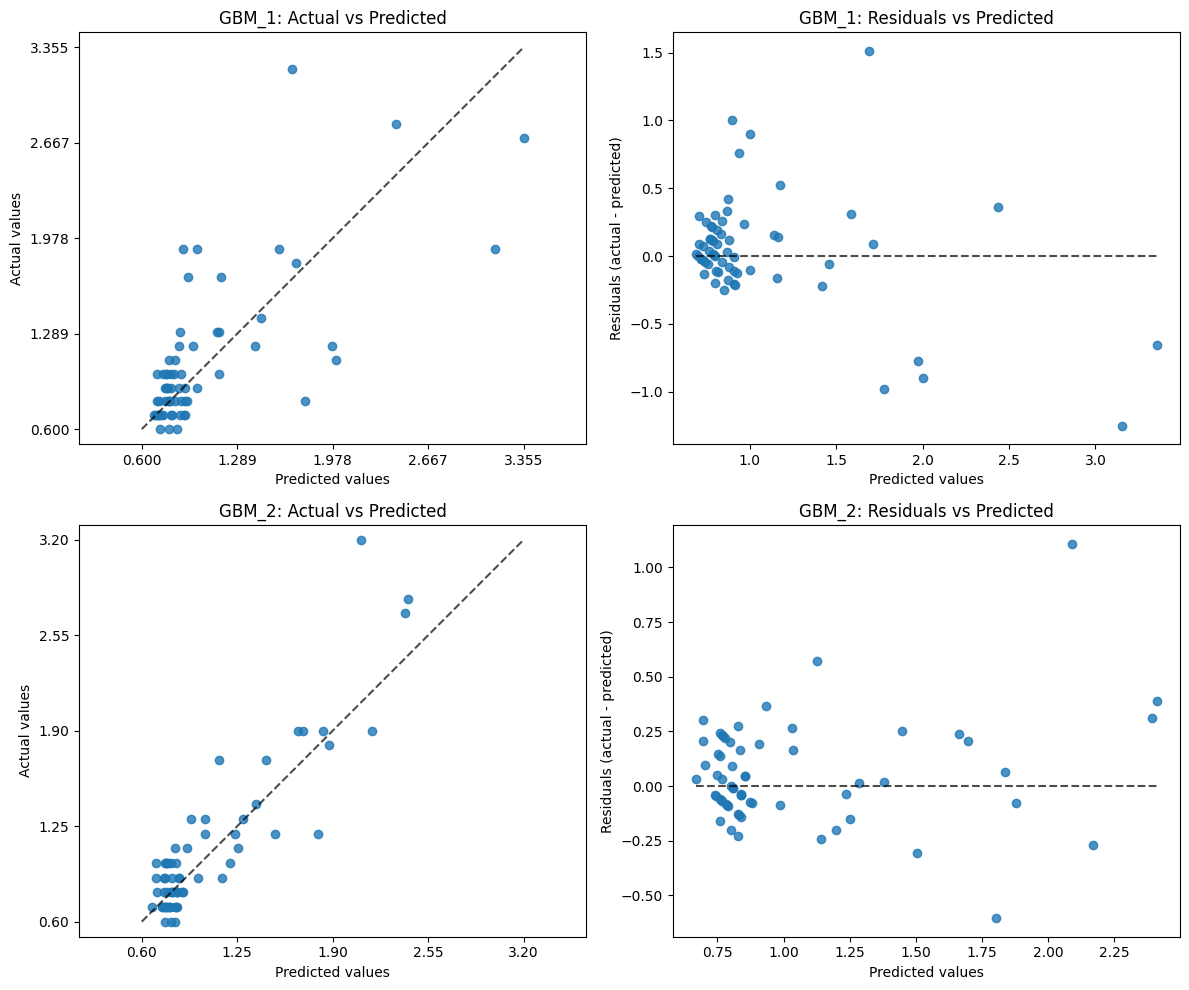

In [57]:
# Plot residual diagnostics for gbm_1 and gbm_2 on the held-out test set
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

PredictionErrorDisplay.from_estimator(
    gbm_1,
    X_test,
    y_test,
    kind='actual_vs_predicted',
    ax=axes[0, 0],
)
axes[0, 0].set_title('GBM_1: Actual vs Predicted')

PredictionErrorDisplay.from_estimator(
    gbm_1,
    X_test,
    y_test,
    kind='residual_vs_predicted',
    ax=axes[0, 1],
)
axes[0, 1].set_title('GBM_1: Residuals vs Predicted')

PredictionErrorDisplay.from_estimator(
    gbm_2,
    X_test,
    y_test,
    kind='actual_vs_predicted',
    ax=axes[1, 0],
)
axes[1, 0].set_title('GBM_2: Actual vs Predicted')

PredictionErrorDisplay.from_estimator(
    gbm_2,
    X_test,
    y_test,
    kind='residual_vs_predicted',
    ax=axes[1, 1],
)
axes[1, 1].set_title('GBM_2: Residuals vs Predicted')

plt.tight_layout()
plt.show()

# Hints:
# - PredictionErrorDisplay.from_estimator for gbm_1 and gbm_2 on X_test, y_test
# - Plot actual_vs_predicted and residual_vs_predicted (a 2×2 subplot layout works well)
# - Prioritise test-set panels when interpreting overfitting


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: residual plots**

**How to read this**
- In the actual-vs-predicted plot, good predictions lie close to the diagonal line.
- In the residual plot, points should be scattered around zero without a clear pattern.
- Curves or funnels in the residuals suggest that the model is missing something systematic.
- Large residuals show observations where the model made a large error.
- Focus especially on the test plots, because these represent unseen data.

**In this notebook**

The figure compares the overfit `gbm_1` in the top row with the tuned `gbm_2` in the bottom row.

| Panel | Overfit GBM | Tuned GBM |
|-------|-------------|-----------|
| Actual vs predicted (test) | Many points are far from the diagonal | Points are closer to the diagonal |
| Residuals vs predicted (test) | Errors have a larger spread | Errors are more centred around zero |

This matches the metrics. Test R² improves from 0.38 to 0.68 after tuning. The overfit model looks almost perfect on the training data, but much worse on the test data. That is the visual sign of overfitting.
</div>



## 9. Performance summary

A compact comparison makes the main lesson easier to read: the tuned pipeline should outperform the dummy baseline, while the overfit model should show the largest train-test gap.


In [58]:
# Baseline: predict the training mean
baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)

# Optional robust baseline: predict the training median
baseline_median = DummyRegressor(strategy='median')
baseline_median.fit(X_train, y_train)

models_to_compare = {
    'Dummy mean baseline': baseline_mean,
    'Dummy median baseline': baseline_median,
    'Overfit GBM': gbm_1,
    'Tuned GBM': gbm_2,
}

model_summary = pd.DataFrame([
    {'Model': model_name, **train_test_diagnostics(model, X_train, y_train, X_test, y_test)}
    for model_name, model in models_to_compare.items()
])

baseline_test_rmse = model_summary.loc[
    model_summary['Model'] == 'Dummy mean baseline', 'Test RMSE'
].iloc[0]

model_summary['Relative RMSE improvement vs mean baseline'] = (
    baseline_test_rmse - model_summary['Test RMSE']
) / baseline_test_rmse

model_summary = model_summary.round(3)

print(model_summary.to_string(index=False))

                Model  Train R2  Test R2  Delta R2  Generalisation ratio  Train RMSE  Test RMSE  Delta RMSE  RMSE ratio  Train MAE  Test MAE  Relative RMSE improvement vs mean baseline
  Dummy mean baseline     0.000   -0.033     0.033                   NaN       0.463      0.542       0.079       1.170      0.296     0.345                                       0.000
Dummy median baseline    -0.047   -0.136     0.089                 2.898       0.474      0.569       0.095       1.200      0.257     0.337                                      -0.049
          Overfit GBM     1.000    0.392     0.608                 0.392       0.000      0.416       0.416    1441.220      0.000     0.264                                       0.233
            Tuned GBM     0.957    0.794     0.163                 0.830       0.096      0.242       0.146       2.514      0.077     0.170                                       0.554


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: performance summary**

**How to read this**
- Always compare a complex model with a simple dummy baseline.
- A model can beat the baseline and still overfit.
- Look at both test performance and the train-test gap.
- RMSE tells you the error size in bBHB units. Delta R² tells you how much the model may be overfitting.

**In this notebook**

| Model | Test R² | Delta R² | Test RMSE | vs mean baseline |
|-------|---------|----------|-----------|------------------|
| Dummy mean baseline | -0.03 | 0.03 | 0.542 | reference |
| Dummy median baseline | -0.14 | 0.09 | 0.569 | worse than mean |
| **Overfit GBM** | **0.38** | **0.62** | 0.420 | 22% lower RMSE, but severe overfitting |
| **Tuned GBM** | **0.68** | **0.27** | **0.301** | **45% lower RMSE** |

The overfit model is better than the dummy baseline, but it is not trustworthy because Train R² is 1.0. The tuned model is the best choice here. It has the best test score, the lowest test RMSE, and a much smaller gap than the overfit model.
</div>



<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

## 10. Final interpretation checklist

Overfitting is likely when:

- Train R² is much higher than Test R².
- Delta R² is large compared with CV variability.
- Train RMSE is much lower than Test RMSE.
- Per-fold train scores are consistently better than validation scores.
- Learning or validation curves show a persistent train–validation gap.
- Test residuals show systematic patterns or large errors.

A model is more trustworthy when:

- It beats the dummy baseline on test data.
- CV performance and test performance agree.
- CV variability is not excessive.
- Train–test gaps are small.
- Residuals on test data are randomly centred around zero.
- Test RMSE is acceptable in the scientific units of the target.

Remember: R² and RMSE should be interpreted together. R² describes relative explained variance; RMSE describes absolute prediction error in bBHB units.

**This notebook's output — summary**
- Overfit GBM: Train R² = 1.0, Test R² = 0.38, Delta R² = 0.62 → clear overfitting.
- CV mean R² = 0.65 but per-fold gaps and fold 3 (Val R² = 0.44) showed instability.
- Tuned GBM: Test R² = 0.68, Delta R² = 0.27, selection optimism gap ≈ 0 → healthier and useful.
</div>

